# Investigation 01


In [81]:
import ast
import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [82]:
# ---------- Main toggles ----------
METHOD = "CN"
ORGAN = "Colon"   # "Colon", "Duodenum", or None
NO_SELF = False
SUBSET_RULE_ITEMS_EQ = 2
SUBSET_MIN_SUPPORT = 0.015

# ---------- Stage config ----------
STAGE_COLUMN = "Pathological score"  # e.g., "Pathological stage", "Clinical score", "GI stage" 

# ---------- Plot config ----------
TOP_RULES_PER_STAGE = 10
FIG_SIZE = (18, 12)
HEATMAP_CMAP = "YlOrRd"

# ---------- Data paths ----------
ALGO = "weighted_fpgrowth"
DATA_ROOT = fr"results\full_run\{ALGO}\data"
RAW_RESULTS_FILE = os.path.join('..', '..', DATA_ROOT, f"results_{METHOD}.csv")

print("METHOD:", METHOD)
print("ORGAN:", ORGAN)
print("NO_SELF:", NO_SELF)
print("SUBSET_RULE_ITEMS_EQ:", SUBSET_RULE_ITEMS_EQ)
print("SUBSET_MIN_SUPPORT:", SUBSET_MIN_SUPPORT)
print("RAW_RESULTS_FILE:", RAW_RESULTS_FILE)


METHOD: CN
ORGAN: Colon
NO_SELF: False
SUBSET_RULE_ITEMS_EQ: 2
SUBSET_MIN_SUPPORT: 0.015
RAW_RESULTS_FILE: ..\..\results\full_run\weighted_fpgrowth\data\results_CN.csv


In [83]:
# Show zero-values cells in gray
def show_zero_values_as_gray(cmap = "RdBu_r"):
    heatmap_cmap = plt.get_cmap(cmap).copy()
    heatmap_cmap.set_bad("#f2f2f2")
    return heatmap_cmap


def _draw_heatmap_panel(
    ax_heat,
    ax_cbar,
    plot_df,
    annotation_df,
    heatmap_cmap,
    heatmap_norm,
    colorbar_label,
    annotation_fontsize,
    title_text,
):
    heatmap_obj = sns.heatmap(
        plot_df,
        annot=annotation_df,
        fmt="",
        annot_kws={"fontsize": annotation_fontsize},
        cmap=heatmap_cmap,
        norm=heatmap_norm,
        linewidths=0.5,
        linecolor="lightgray",
        cbar_ax=ax_cbar,
        cbar_kws={"label": colorbar_label},
        ax=ax_heat,
    )
    colorbar = heatmap_obj.collections[0].colorbar
    colorbar.set_label(colorbar_label, fontsize=10, labelpad=8)
    colorbar.ax.tick_params(labelsize=9, pad=2)
    ax_heat.set_title(title_text, pad=20, loc="left", fontsize=11, fontweight="bold", linespacing=1.5)
    ax_heat.set_xlabel("")
    ax_heat.set_ylabel("Rule")


def _draw_violin_panel(ax_violin, meta_df, rule_order, rule_col, metadata_value_col, heat_ylim):
    row_centers = np.arange(len(rule_order)) + 0.5
    if meta_df.empty:
        ax_violin.text(0.5, 0.5, f"No {metadata_value_col} data", ha="center", va="center", transform=ax_violin.transAxes)
    else:
        for row_index, rule in enumerate(rule_order):
            values = meta_df.loc[meta_df[rule_col] == rule, metadata_value_col].dropna().values
            if len(values) == 0:
                continue
            violin = ax_violin.violinplot(
                dataset=[values],
                positions=[row_centers[row_index]],
                vert=False,
                widths=0.78,
                showmeans=False,
                showextrema=False,
                showmedians=False,
            )
            for body in violin["bodies"]:
                body.set_facecolor("#9ecae1")
                body.set_edgecolor("#6baed6")
                body.set_alpha(0.85)
            mean_value = float(np.mean(values))
            ax_violin.vlines(
                mean_value,
                row_centers[row_index] - 0.28,
                row_centers[row_index] + 0.28,
                color="#08306b",
                linewidth=1.3,
                zorder=4,
            )

    ax_violin.set_ylim(heat_ylim)
    ax_violin.set_yticks(row_centers)
    ax_violin.set_title(f"{metadata_value_col} Distribution", pad=16)
    ax_violin.set_xlabel(metadata_value_col)
    ax_violin.set_ylabel("")
    ax_violin.set_yticklabels([])
    ax_violin.grid(False)
    ax_violin.grid(axis="x", color="lightgray", linewidth=0.6, alpha=0.7)
    ax_violin.yaxis.grid(False)


def _draw_metadata_table_panel(ax_table, stage_order, rule_order, table_rows, heat_ylim, metadata_value_col):
    ax_table.set_xlim(0, len(stage_order))
    ax_table.set_ylim(heat_ylim)
    ax_table.set_xticks([])
    ax_table.set_yticks([])
    for spine in ax_table.spines.values():
        spine.set_visible(False)

    for col_index, stage in enumerate(stage_order):
        ax_table.text(
            col_index + 0.5,
            -0.12,
            f"S{stage}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            clip_on=False,
        )

    for row_index, _ in enumerate(rule_order):
        y_pos = row_index + 0.5
        for col_index, _ in enumerate(stage_order):
            ax_table.text(
                col_index + 0.5,
                y_pos,
                table_rows[row_index][col_index],
                ha="center",
                va="center",
                fontsize=8,
            )

    ax_table.set_title(f"{metadata_value_col} Mean ± Std", pad=34)


def _draw_shared_guides(ax_heat, ax_violin, ax_table, row_count, stage_count):
    for y_line in range(row_count + 1):
        ax_heat.axhline(y=y_line, color="lightgray", linewidth=0.7, zorder=3)
        ax_violin.axhline(y=y_line, color="lightgray", linewidth=0.7, zorder=3)
        ax_table.axhline(y=y_line, color="lightgray", linewidth=0.7, zorder=3)

    for x_line in range(stage_count + 1):
        ax_table.plot([x_line, x_line], [0, row_count], color="lightgray", linewidth=0.6)


def plot_rule_stage_panels(
    score_matrix,
    metadata_df,
    stage_count_rows,
    rule_col="Rule",
    stage_col=STAGE_COLUMN,
    metadata_value_col="Lift",
    fov_col="FOV",
    heatmap_cmap="YlOrRd",
    colorbar_label="Consensus Score",
    heatmap_center=None,
    annotation_fontsize=None,
):
    stage_counts = (
        stage_count_rows[[stage_col, "Total_FOVs_In_Stage"]]
        .drop_duplicates()
        .set_index(stage_col)["Total_FOVs_In_Stage"]
        .to_dict()
    )
    stage_counts = {str(k): int(v) for k, v in stage_counts.items()}

    rule_order = score_matrix.index.tolist()
    stage_order = [str(x) for x in score_matrix.columns]
    row_count = max(len(rule_order), 1)
    fig_height = max(10, min(0.38 * row_count + 4, 30))
    fig_size = (25, fig_height)
    if annotation_fontsize is None:
        annotation_fontsize = 8 if row_count <= 25 else 6

    plot_df = score_matrix.copy()
    plot_df = plot_df.rename(columns={s: f"Stage {s}\n(N={stage_counts.get(s, 0)})" for s in stage_order})

    meta_df = metadata_df.copy()
    meta_df = meta_df[meta_df[rule_col].isin(rule_order)].copy()
    meta_df[stage_col] = meta_df[stage_col].astype(str)

    stats_df = meta_df.groupby([rule_col, stage_col])[metadata_value_col].agg(["mean", "std"]).reset_index()
    mean_tbl = stats_df.pivot(index=rule_col, columns=stage_col, values="mean").reindex(index=rule_order, columns=stage_order)
    std_tbl = stats_df.pivot(index=rule_col, columns=stage_col, values="std").reindex(index=rule_order, columns=stage_order)
    rule_stage_fov_counts = meta_df.groupby([rule_col, stage_col])[fov_col].nunique().reset_index(name="fov_count")
    count_tbl = rule_stage_fov_counts.pivot(index=rule_col, columns=stage_col, values="fov_count").reindex(index=rule_order, columns=stage_order).fillna(0).astype(int)

    table_rows = []
    for rule in rule_order:
        row_cells = []
        for stage in stage_order:
            n = int(count_tbl.at[rule, stage])
            if n == 0:
                row_cells.append("—")
            else:
                mean_value = mean_tbl.at[rule, stage]
                std_value = std_tbl.at[rule, stage]
                std_text = f"{std_value:.2f}" if pd.notna(std_value) else "0.00"
                row_cells.append(f"{mean_value:.2f}±{std_text}\n(n={n})")
        table_rows.append(row_cells)

    score_tbl = score_matrix.copy()
    score_tbl.columns = [str(x) for x in score_tbl.columns]
    score_tbl = score_tbl.reindex(index=rule_order, columns=stage_order)
    heatmap_norm = None
    if heatmap_center is not None:
        min_score = float(np.nanmin(score_tbl.values))
        max_score = float(np.nanmax(score_tbl.values))
        if min_score < heatmap_center < max_score:
            heatmap_norm = mcolors.TwoSlopeNorm(vmin=min_score, vcenter=heatmap_center, vmax=max_score)
    heatmap_annotations = pd.DataFrame(index=rule_order, columns=plot_df.columns)
    for rule in rule_order:
        for stage in stage_order:
            value = score_tbl.at[rule, stage]
            display_value = 0.0 if pd.isna(value) else float(value)
            n = int(count_tbl.at[rule, stage])
            heatmap_annotations.at[rule, f"Stage {stage}\n(N={stage_counts.get(stage, 0)})"] = f"{display_value:.2f}\n(n={n})"

    organ_text = ORGAN if ORGAN is not None else "All"
    title_lines = [
        f"{colorbar_label} ({METHOD} | {ALGO})",
        f"Organ: {organ_text}  |  Stage Col: {stage_col}  |  Top Rules/Stage: {TOP_RULES_PER_STAGE}",
        f"Filters: No Self-Loops={NO_SELF}  |  Items={SUBSET_RULE_ITEMS_EQ}  |  Min Support={SUBSET_MIN_SUPPORT}"
    ]
    title_text = "\n".join(title_lines)

    fig = plt.figure(figsize=fig_size)
    grid = fig.add_gridspec(1, 4, width_ratios=[3.4, 1.2, 2.6, 0.24], wspace=0.06)
    ax_heat = fig.add_subplot(grid[0, 0])
    ax_violin = fig.add_subplot(grid[0, 1])
    ax_table = fig.add_subplot(grid[0, 2])
    ax_cbar = fig.add_subplot(grid[0, 3])

    _draw_heatmap_panel(
        ax_heat,
        ax_cbar,
        plot_df,
        heatmap_annotations,
        heatmap_cmap,
        heatmap_norm,
        colorbar_label,
        annotation_fontsize,
        title_text,
    )
    heat_ylim = ax_heat.get_ylim()

    _draw_violin_panel(ax_violin, meta_df, rule_order, rule_col, metadata_value_col, heat_ylim)
    _draw_metadata_table_panel(ax_table, stage_order, rule_order, table_rows, heat_ylim, metadata_value_col)
    _draw_shared_guides(ax_heat, ax_violin, ax_table, len(rule_order), len(stage_order))

    fig.subplots_adjust(left=0.035, right=0.985, top=0.93, bottom=0.06, wspace=0.06)
    return fig



def _add_organ_metadata(work_df):
    import os
    import pandas as pd
    
    if "Organ" in work_df.columns:
        return work_df
        
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")

    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")

        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"

        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    return work_df


### Preparing Basic Data

In [84]:
raw_results_df = pd.read_csv(RAW_RESULTS_FILE)
print("raw_results_df:", raw_results_df.shape)
raw_results_df = raw_results_df[raw_results_df["FDR"] <= 0.01]
print("raw_results_df:", raw_results_df.shape)
raw_results_df.head(3)


raw_results_df: (209516, 22)
raw_results_df: (109858, 22)


,FOV,Antecedents,Consequents,Lift,Confidence,Conviction,Support,P_Value,FDR,Rule_Count_Global,...,Cortico Response,Survival at follow-up,GI stage,Grade GVHD,liver stage,skin stage,Pathological stage,Clinical score,Pathological score,Group
95,Control_01_FOV_1,"['CD8T_CD69+_CENTER', 'CD8T_GZMB+_NEIGHBOR']","['CD8T_CD69+_NEIGHBOR', 'CD8T_CENTER', 'Macrop...",35.603302,0.927833,13.495567,0.010608,0.000999,0.003265,19,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
96,Control_01_FOV_1,"['CD8T_CD69+_NEIGHBOR', 'CD8T_CENTER', 'Macrop...","['CD8T_CD69+_CENTER', 'CD8T_GZMB+_NEIGHBOR']",35.603302,0.407063,1.667237,0.010608,0.000999,0.003265,3,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0
108,Control_01_FOV_1,"['CD8T_CD69+_CENTER', 'CD8T_CD69+_NEIGHBOR', '...","['CD8T_CENTER', 'CD8T_GZMB+_NEIGHBOR']",35.246753,0.442918,1.772510,0.010608,0.000999,0.003265,1,...,Control,Control,0.0,0.0,0.0,0.0,0.0,Control,Control,0.0


In [85]:
def _to_lineage(cell_label):
        cell_label = str(cell_label)
        if cell_label.endswith("+") and "_" in cell_label:
            return cell_label.rsplit("_", 1)[0]
        return cell_label

def _create_basic_dataset():
    work_df = raw_results_df.copy()

    # --- Standardized Organ Enrichment (Inlined from visualization_util logic) ---
    mibi_gut_dir_path = os.path.join("..", "..", "data", "MIBIGutCsv")
    biopsy_path = os.path.join(mibi_gut_dir_path, "biopsy_metadata.csv")
    fovs_path = os.path.join(mibi_gut_dir_path, "fovs_metadata.csv")
    
    if os.path.exists(biopsy_path) and os.path.exists(fovs_path):
        df_biopsy = pd.read_csv(biopsy_path)
        df_fovs = pd.read_csv(fovs_path)
        unique_biopsies = df_fovs[~df_fovs["FOV"].astype(str).str.startswith("S_")][["Patient", "Cohort"]].drop_duplicates().rename(columns={"Patient": "Biopsy_ID"})
        meta = pd.merge(unique_biopsies, df_biopsy[["Biopsy_ID", "Localization"]], on="Biopsy_ID", how="left")
        
        def get_organ(row):
            if pd.notna(row.get("Localization")): return row["Localization"]
            cohort = str(row.get("Cohort", ""))
            if "Colon" in cohort: return "Colon"
            if "Duodenum" in cohort: return "Duodenum"
            return "Unknown"
        
        meta["Organ"] = meta.apply(get_organ, axis=1)
        work_df = work_df.merge(meta[["Biopsy_ID", "Organ"]], on="Biopsy_ID", how="left")
    # -----------------------------------------------------------------------------

    # Parse and clean rule items once
    work_df["ant_items"] = work_df["Antecedents"].apply(ast.literal_eval)
    work_df["con_items"] = work_df["Consequents"].apply(ast.literal_eval)
    work_df["ant_clean"] = work_df["ant_items"].apply(lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items])
    work_df["con_clean"] = work_df["con_items"].apply(lambda items: [str(x).replace("_CENTER", "").replace("_NEIGHBOR", "") for x in items])

    work_df["ant_lineage"] = work_df["ant_clean"].apply(lambda items: [_to_lineage(x) for x in items])
    work_df["con_lineage"] = work_df["con_clean"].apply(lambda items: [_to_lineage(x) for x in items])

    # Optional no-self filter
    if NO_SELF:
        has_overlap = work_df.apply(
            lambda row: len(set(row["ant_lineage"]).intersection(set(row["con_lineage"]))) > 0,
            axis=1,
        )
        work_df = work_df[~has_overlap].copy()

    # Optional subset filters
    if SUBSET_RULE_ITEMS_EQ is not None:
        rule_item_count = work_df.apply(lambda row: len(row["ant_clean"]) + len(row["con_clean"]), axis=1)
        work_df = work_df[rule_item_count == int(SUBSET_RULE_ITEMS_EQ)].copy()

    if SUBSET_MIN_SUPPORT is not None:
        work_df = work_df[work_df["Support"] >= float(SUBSET_MIN_SUPPORT)].copy()

    if ORGAN is not None:
        if "Organ" in work_df.columns:
            print(f"Filtering by organ: {ORGAN}")
            work_df = work_df[work_df["Organ"] == ORGAN].copy()
        else:
            print(f"Warning: ORGAN filter '{ORGAN}' specified but 'Organ' column not found in data.")

    # --- Safeguard ---
    if work_df.empty:
        print("Dataset is empty after filtering! Returning early.")
        return work_df
    # -----------------

    work_df["Rule"] = work_df.apply(
        lambda row: f"{', '.join(row['ant_clean'])} -> {', '.join(row['con_clean'])}",
        axis=1,
    )

    print(f"Unique stages in data for {STAGE_COLUMN}:", work_df[STAGE_COLUMN].unique())
    
    unique_stages = work_df[STAGE_COLUMN].dropna().unique()
    if set(unique_stages).issubset({"Control", "Mild", "Severe"}):
        order = ["Control", "Mild", "Severe"]
        order = [x for x in order if x in unique_stages]
    else:
        order = sorted(unique_stages)
        
    # Ensure they appear in the right order
    work_df[STAGE_COLUMN] = pd.Categorical(
        work_df[STAGE_COLUMN],
        categories=order,
        ordered=True
    )
    print("work_df columns:", work_df.columns.tolist())
    return work_df


In [86]:
def build_stage_consensus(work_df):
    # Build stage consensus from filtered rows
    stage_fov_counts = work_df.groupby(STAGE_COLUMN)["FOV"].nunique()
    stage_rule_counts = work_df.groupby([STAGE_COLUMN, "Antecedents", "Consequents", "Rule"], as_index=False)["FOV"].nunique()
    stage_rule_counts = stage_rule_counts.rename(columns={"FOV": "FOV_Count"})
    stage_rule_counts["Total_FOVs_In_Stage"] = stage_rule_counts[STAGE_COLUMN].map(stage_fov_counts).astype(float)
    stage_rule_counts["Consensus_Score"] = stage_rule_counts["FOV_Count"] / stage_rule_counts["Total_FOVs_In_Stage"]

    print("stage_rule_counts columns:", stage_rule_counts.columns.tolist())
    stage_consensus_df = stage_rule_counts.sort_values(["Consensus_Score", "FOV_Count"], ascending=[False, False]).reset_index(drop=True)

    print("stage_consensus_df columns:", stage_consensus_df.columns.tolist())
    return stage_consensus_df



In [87]:
def _select_rules_for_stage_consensus_view():

    work_df = _create_basic_dataset()
    stage_consensus_df = build_stage_consensus(work_df)

    stage_view = stage_consensus_df.copy()

    # Keep one score per Rule x Stage (max is a safety step if duplicates exist)
    stage_scores = stage_view.groupby(["Rule", STAGE_COLUMN], as_index=False)["Consensus_Score"].max()
    # Matrix for heatmap: rows=rules, columns=stages
    stage_matrix = stage_scores.pivot(index="Rule", columns=STAGE_COLUMN, values="Consensus_Score").fillna(0)

    # Select top rules per stage, then take the union
    selected_rules = []
    for stage_value in stage_matrix.columns:
        top_rules = stage_matrix.nlargest(TOP_RULES_PER_STAGE, stage_value).index.tolist()
        for rule in top_rules:
            if rule not in selected_rules:
                selected_rules.append(rule)

    # Final plotting table
    heatmap_df = stage_matrix.loc[selected_rules].copy()
    # Order rules by their strongest stage value
    heatmap_df["row_max_score"] = heatmap_df.max(axis=1)
    heatmap_df = heatmap_df.sort_values("row_max_score", ascending=False).drop(columns="row_max_score")
    heatmap_df.columns = [str(x) for x in heatmap_df.columns]

    return heatmap_df, stage_consensus_df, work_df


Filtering by organ: Colon
Unique stages in data for Pathological score: <StringArray>
['Severe', 'Mild', 'Control']
Length: 3, dtype: str
work_df columns: ['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction', 'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort', 'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD', 'liver stage', 'skin stage', 'Pathological stage', 'Clinical score', 'Pathological score', 'Group', 'Organ', 'ant_items', 'con_items', 'ant_clean', 'con_clean', 'ant_lineage', 'con_lineage', 'Rule']
stage_rule_counts columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
stage_consensus_df columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']


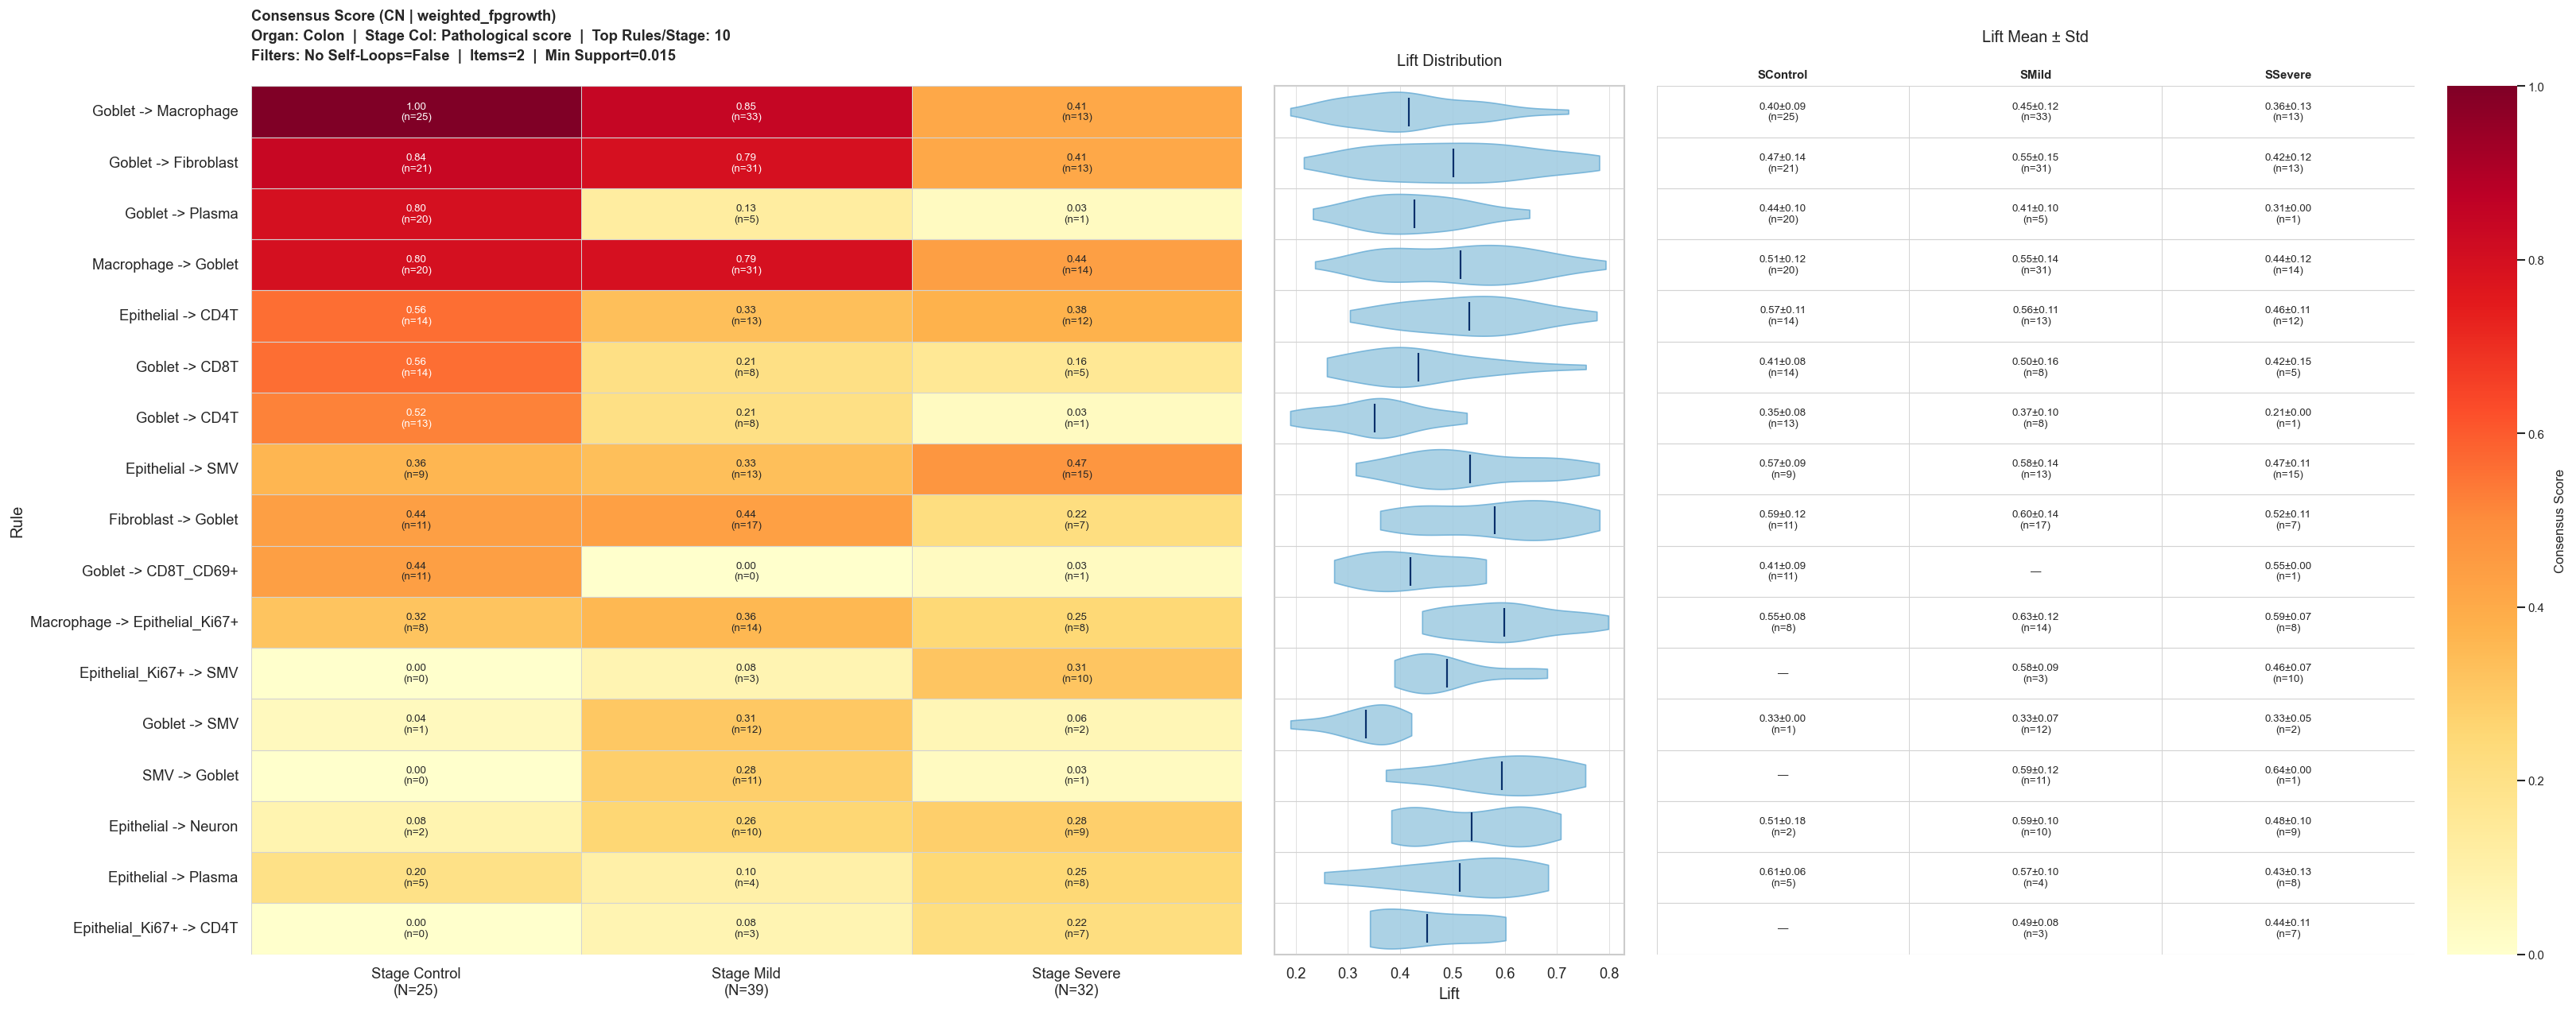

In [88]:
NO_SELF = False
heatmap_df, stage_consensus_df, metadata_df = _select_rules_for_stage_consensus_view()

plot_figure = plot_rule_stage_panels(
    score_matrix=heatmap_df,
    metadata_df=metadata_df,
    stage_count_rows=stage_consensus_df,
)

plt.show()

Filtering by organ: Colon
Unique stages in data for Pathological score: <StringArray>
['Severe', 'Mild', 'Control']
Length: 3, dtype: str
work_df columns: ['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction', 'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort', 'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD', 'liver stage', 'skin stage', 'Pathological stage', 'Clinical score', 'Pathological score', 'Group', 'Organ', 'ant_items', 'con_items', 'ant_clean', 'con_clean', 'ant_lineage', 'con_lineage', 'Rule']
stage_rule_counts columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
stage_consensus_df columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']


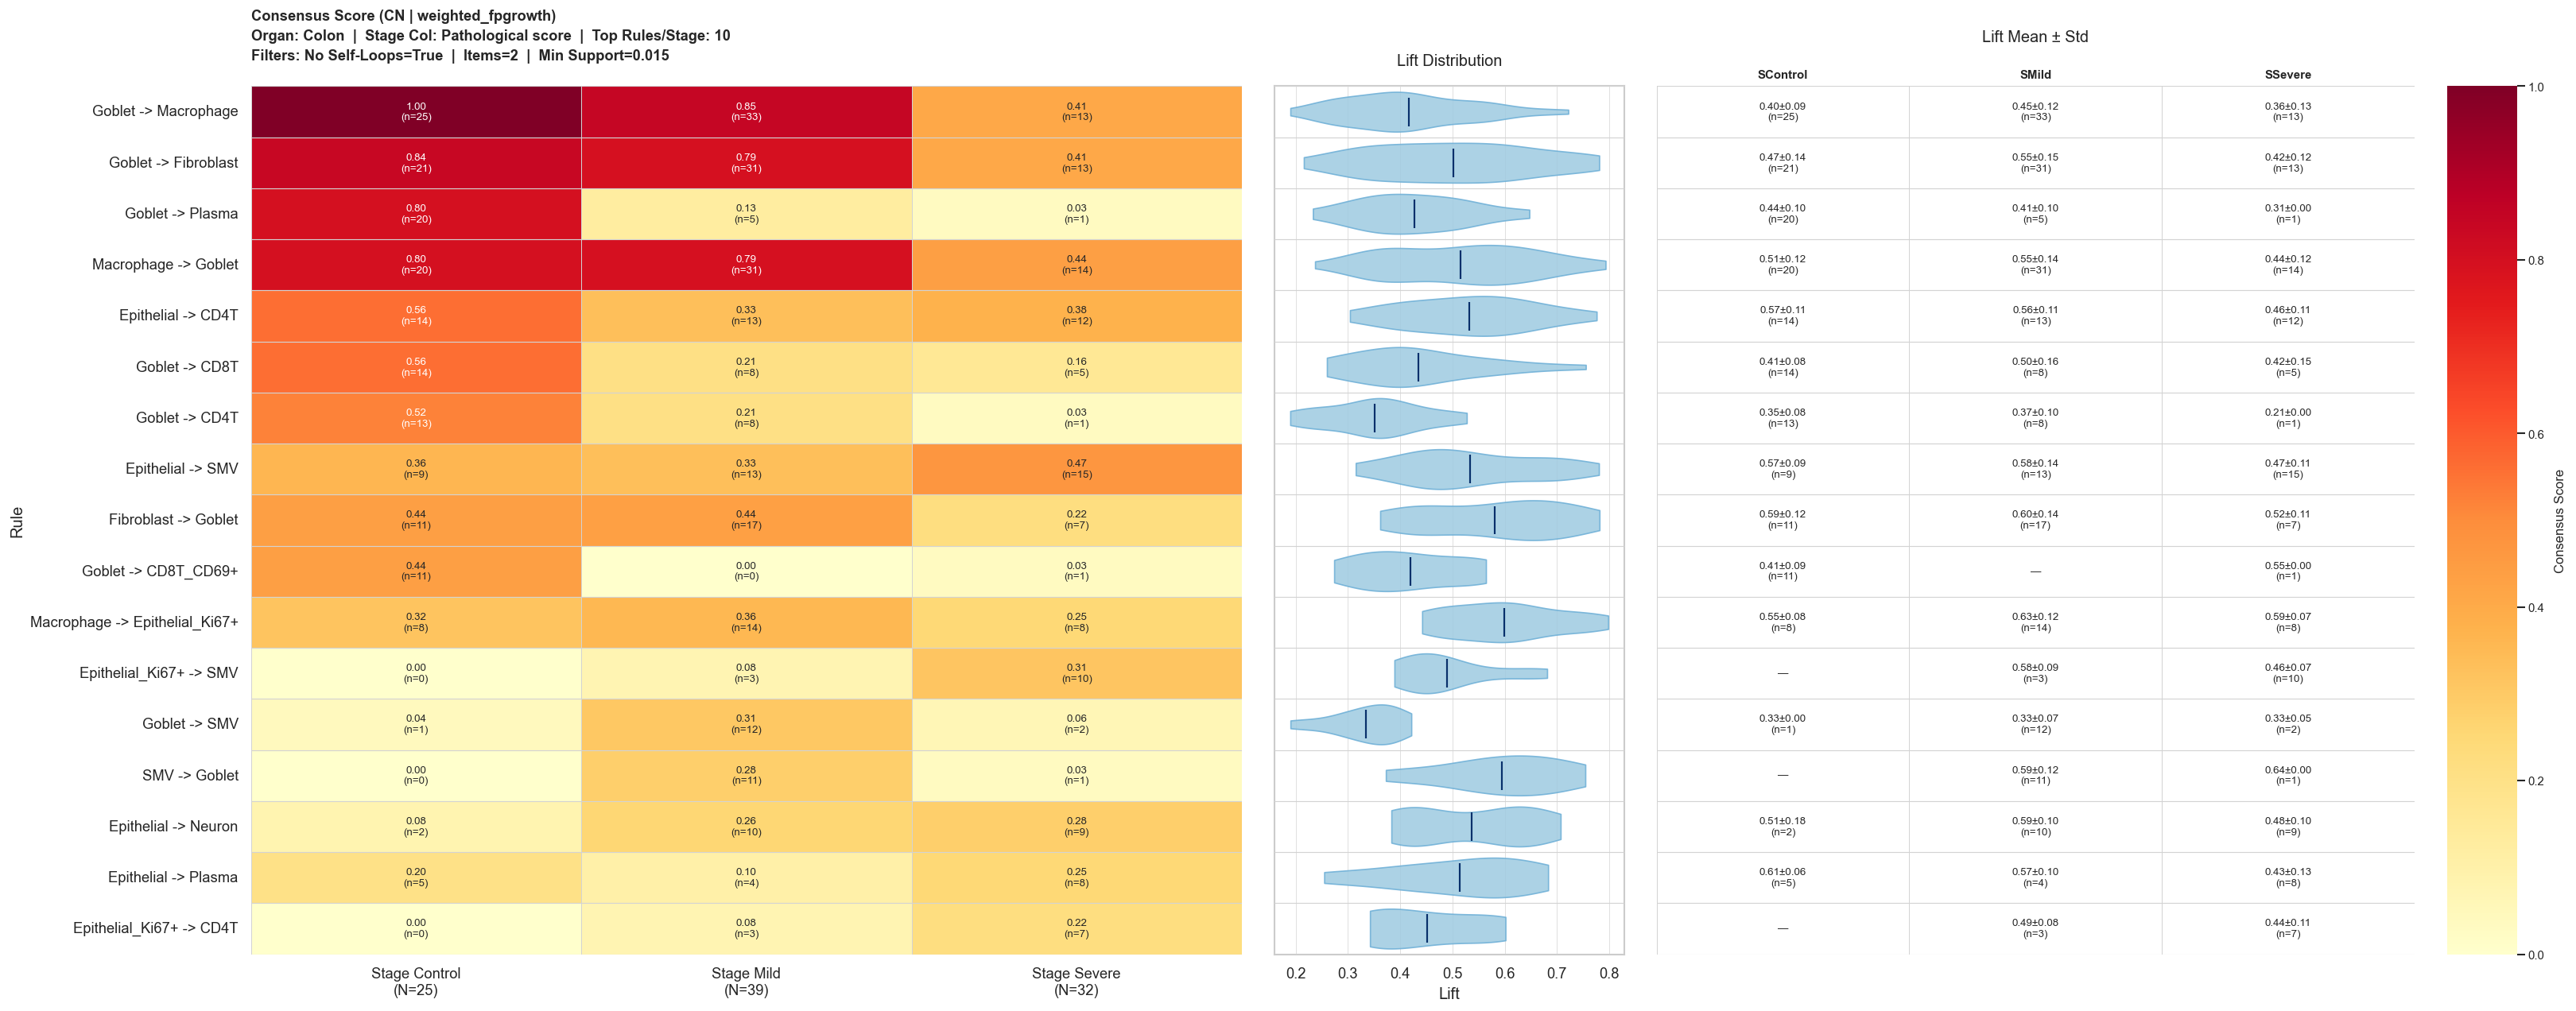

In [89]:
NO_SELF = True
heatmap_df, stage_consensus_df, metadata_df = _select_rules_for_stage_consensus_view()

plot_figure = plot_rule_stage_panels(
    score_matrix=heatmap_df,
    metadata_df=metadata_df,
    stage_count_rows=stage_consensus_df,
)
plt.show()


Filtering by organ: Duodenum
Unique stages in data for Pathological score: <StringArray>
['Control', 'Severe', 'Mild']
Length: 3, dtype: str
work_df columns: ['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction', 'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort', 'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD', 'liver stage', 'skin stage', 'Pathological stage', 'Clinical score', 'Pathological score', 'Group', 'Organ', 'ant_items', 'con_items', 'ant_clean', 'con_clean', 'ant_lineage', 'con_lineage', 'Rule']
stage_rule_counts columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
stage_consensus_df columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']


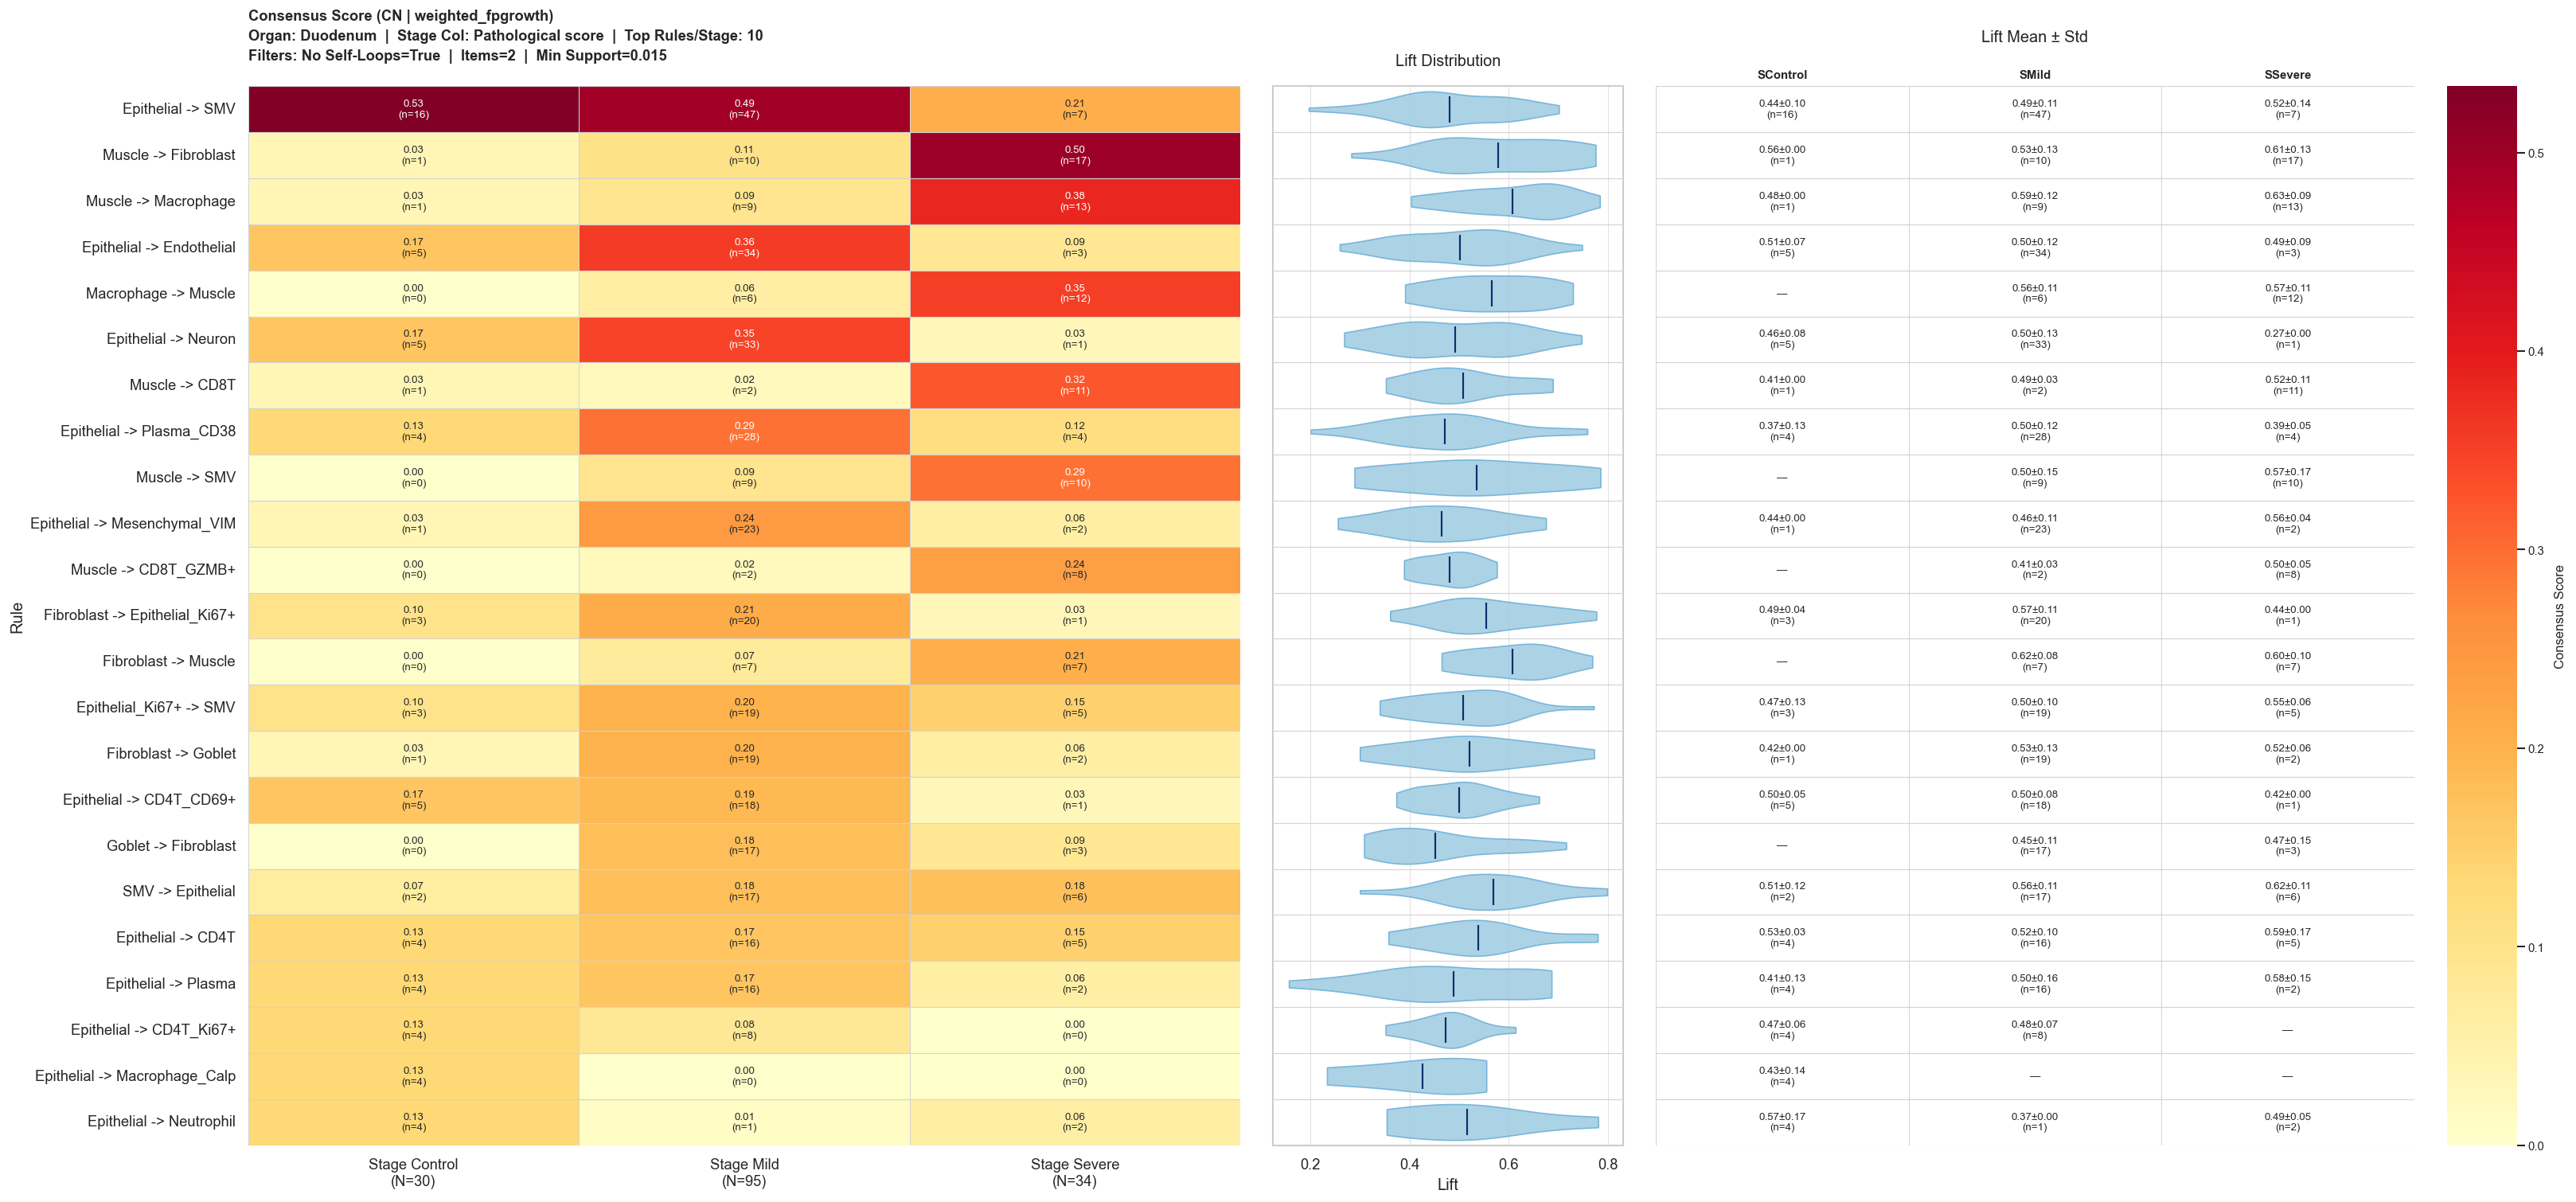

In [90]:
NO_SELF = True
ORGAN = "Duodenum"
heatmap_df, stage_consensus_df, metadata_df = _select_rules_for_stage_consensus_view()

plot_figure = plot_rule_stage_panels(
    score_matrix=heatmap_df,
    metadata_df=metadata_df,
    stage_count_rows=stage_consensus_df,
)
plt.show()


### Lift's Std Heatmap

In [91]:
def _select_rules_by_global_lift_std():
    work_df = _create_basic_dataset()
    stage_consensus_df = build_stage_consensus(work_df)

    # Select rules by global Lift std (missing rule-FOV values are 0)
    std_view = work_df.copy()
    std_view["Rule"] = std_view.apply(
        lambda row: (
            f"{', '.join([str(x).replace('_CENTER', '').replace('_NEIGHBOR', '') for x in ast.literal_eval(row['Antecedents'])])}"
            f" -> "
        f"{', '.join([str(x).replace('_CENTER', '').replace('_NEIGHBOR', '') for x in ast.literal_eval(row['Consequents'])])}"
    ),
    axis=1,
    )

    rule_stage_fov_lift = std_view.groupby(["Rule", STAGE_COLUMN, "FOV"], as_index=False)["Lift"].mean()
    rule_stage_fov_lift["Stage_FOV"] = (
        rule_stage_fov_lift[STAGE_COLUMN].astype(str) + " | " + rule_stage_fov_lift["FOV"].astype(str)
    )

    # Calculate global Lift std for each rule across all stage-FOV combinations (missing values treated as 0)
    # rule_fov_lift_matrix = rule_stage_fov_lift.pivot(index="Rule", columns="Stage_FOV", values="Lift").fillna(0)

    # Alternative: Calculate std only on observed values (missing values not counted as 0)""
    rule_fov_lift_matrix = rule_stage_fov_lift.pivot(index="Rule", columns="Stage_FOV", values="Lift")

    rule_global_lift_std = rule_fov_lift_matrix.std(axis=1)

    # Keep only rules with std > 0
    rule_global_lift_std = rule_global_lift_std[rule_global_lift_std > 0]

    # Pick top rules by global Lift std
    top_rule_count = TOP_RULES_PER_STAGE * std_view[STAGE_COLUMN].nunique()
    std_selected_rules = rule_global_lift_std.nlargest(top_rule_count).index.tolist()

    # Build stage Lift matrix with 0 for non-existing rule-FOV values

    # stage_total_fovs = std_view.groupby(STAGE_COLUMN)["FOV"].nunique()
    # rule_stage_lift_sum = rule_stage_fov_lift.groupby(["Rule", STAGE_COLUMN], as_index=False)["Lift"].sum()
    # rule_stage_lift_sum["Stage_Total_FOVs"] = rule_stage_lift_sum[STAGE_COLUMN].map(stage_total_fovs)
    # rule_stage_lift_sum["Lift_With_Missing_Zero"] = (
    #     rule_stage_lift_sum["Lift"] / rule_stage_lift_sum["Stage_Total_FOVs"]
    # )
    # lift_matrix = (
    #     rule_stage_lift_sum.pivot(index="Rule", columns=STAGE_COLUMN, values="Lift_With_Missing_Zero").fillna(0)
    # )

    # Without counting zero-lift rule-Fovs:

    rule_stage_lift_observed = rule_stage_fov_lift.groupby(["Rule", STAGE_COLUMN], as_index=False)["Lift"].mean()
    lift_matrix = (
        rule_stage_lift_observed.pivot(index="Rule", columns=STAGE_COLUMN, values="Lift")
    )

    std_selected_lift_matrix = lift_matrix.loc[std_selected_rules].copy()
    std_selected_lift_matrix.columns = [str(x) for x in std_selected_lift_matrix.columns]
    lift_heatmap_matrix = std_selected_lift_matrix.replace(0, np.nan)

    print("rule x stage-fov matrix shape:", rule_fov_lift_matrix.shape)
    print("selected rules:", len(std_selected_rules))
    print("stage lift matrix shape:", lift_matrix.shape)
    print("selected lift matrix shape:", std_selected_lift_matrix.shape)
    std_selected_lift_matrix.head(5)

    return lift_heatmap_matrix, stage_consensus_df, work_df


Filtering by organ: Duodenum
Unique stages in data for Pathological score: <StringArray>
['Control', 'Severe', 'Mild']
Length: 3, dtype: str
work_df columns: ['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction', 'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort', 'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD', 'liver stage', 'skin stage', 'Pathological stage', 'Clinical score', 'Pathological score', 'Group', 'Organ', 'ant_items', 'con_items', 'ant_clean', 'con_clean', 'ant_lineage', 'con_lineage', 'Rule']
stage_rule_counts columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
stage_consensus_df columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
rule x stage-fov matrix shape: (232, 160)
selected rules: 30
stage lift matrix shape: (232, 3)
selected lift matrix shape: (30, 3)


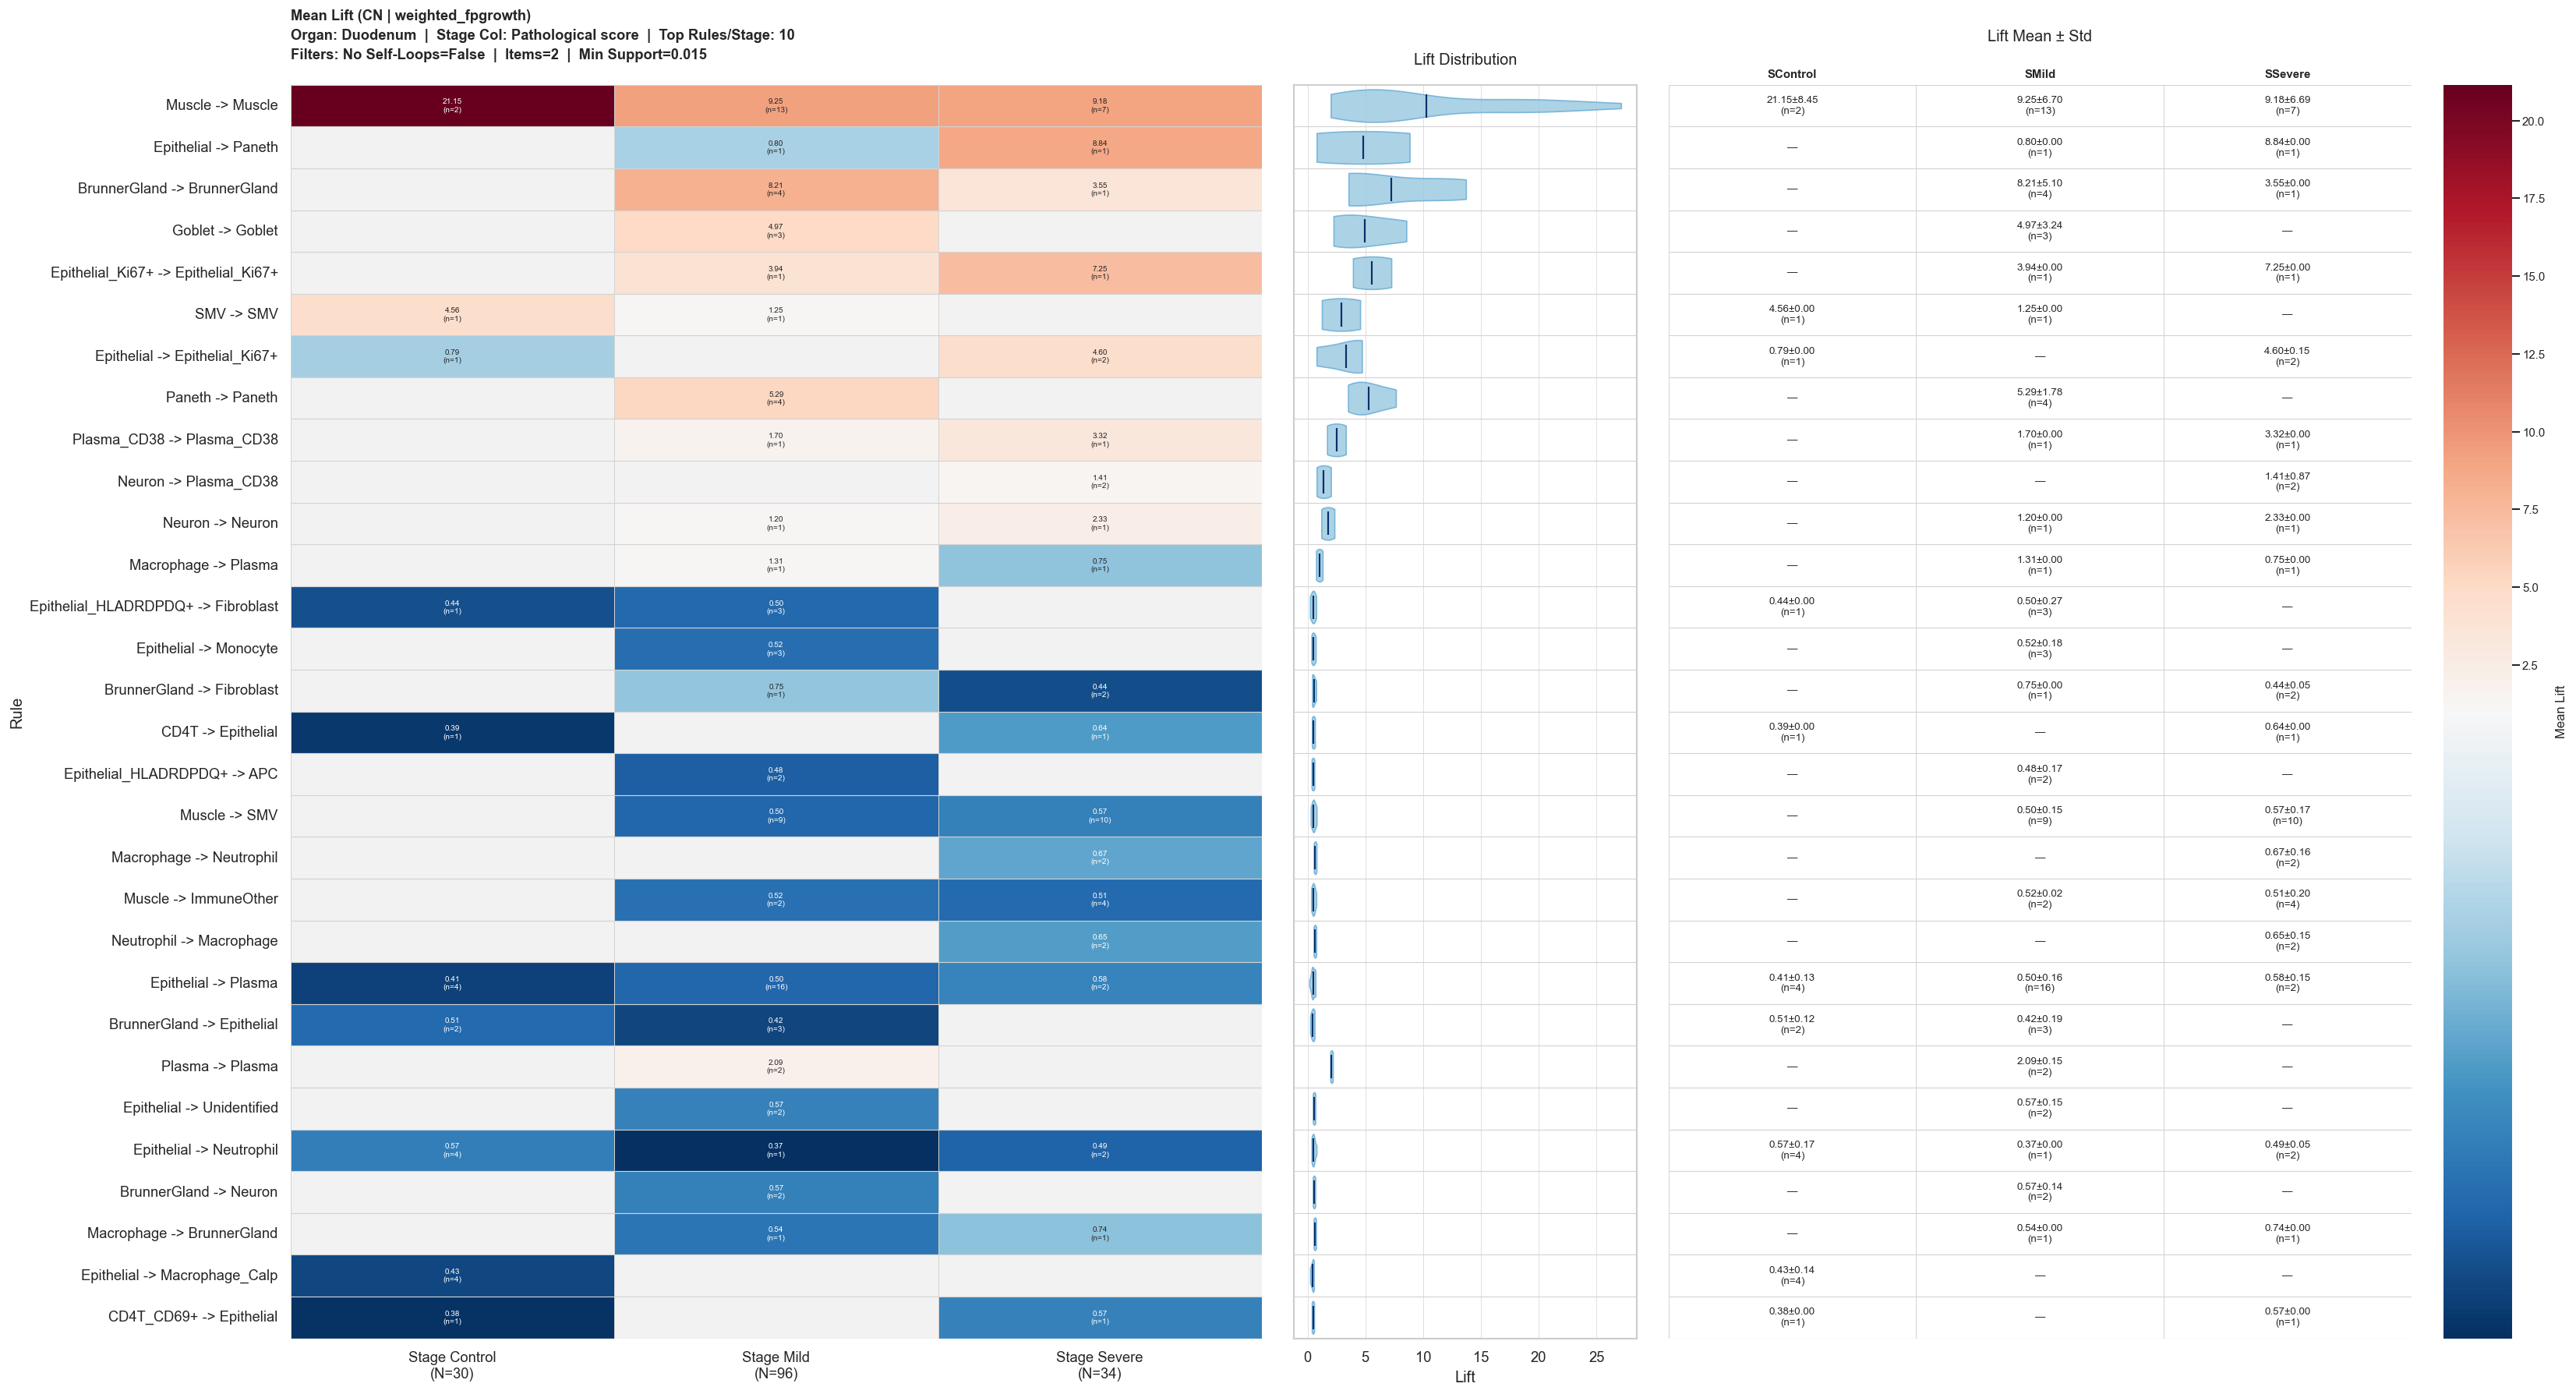

In [92]:
NO_SELF = False


confidence_heatmap_matrix, stage_consensus_df, metadata_df = _select_rules_by_global_lift_std()
lift_heatmap_cmap = show_zero_values_as_gray()
plot_figure = plot_rule_stage_panels(
    score_matrix=confidence_heatmap_matrix,
    metadata_df=metadata_df,
    stage_count_rows=stage_consensus_df,
    heatmap_cmap=lift_heatmap_cmap,
    colorbar_label="Mean Lift",
    heatmap_center=1.0,
)
plt.show()


Filtering by organ: Duodenum
Unique stages in data for Pathological score: <StringArray>
['Control', 'Severe', 'Mild']
Length: 3, dtype: str
work_df columns: ['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction', 'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort', 'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD', 'liver stage', 'skin stage', 'Pathological stage', 'Clinical score', 'Pathological score', 'Group', 'Organ', 'ant_items', 'con_items', 'ant_clean', 'con_clean', 'ant_lineage', 'con_lineage', 'Rule']
stage_rule_counts columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
stage_consensus_df columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
rule x stage-fov matrix shape: (217, 159)
selected rules: 30
stage lift matrix shape: (217, 3)
selected lift matrix shape: (30, 3)


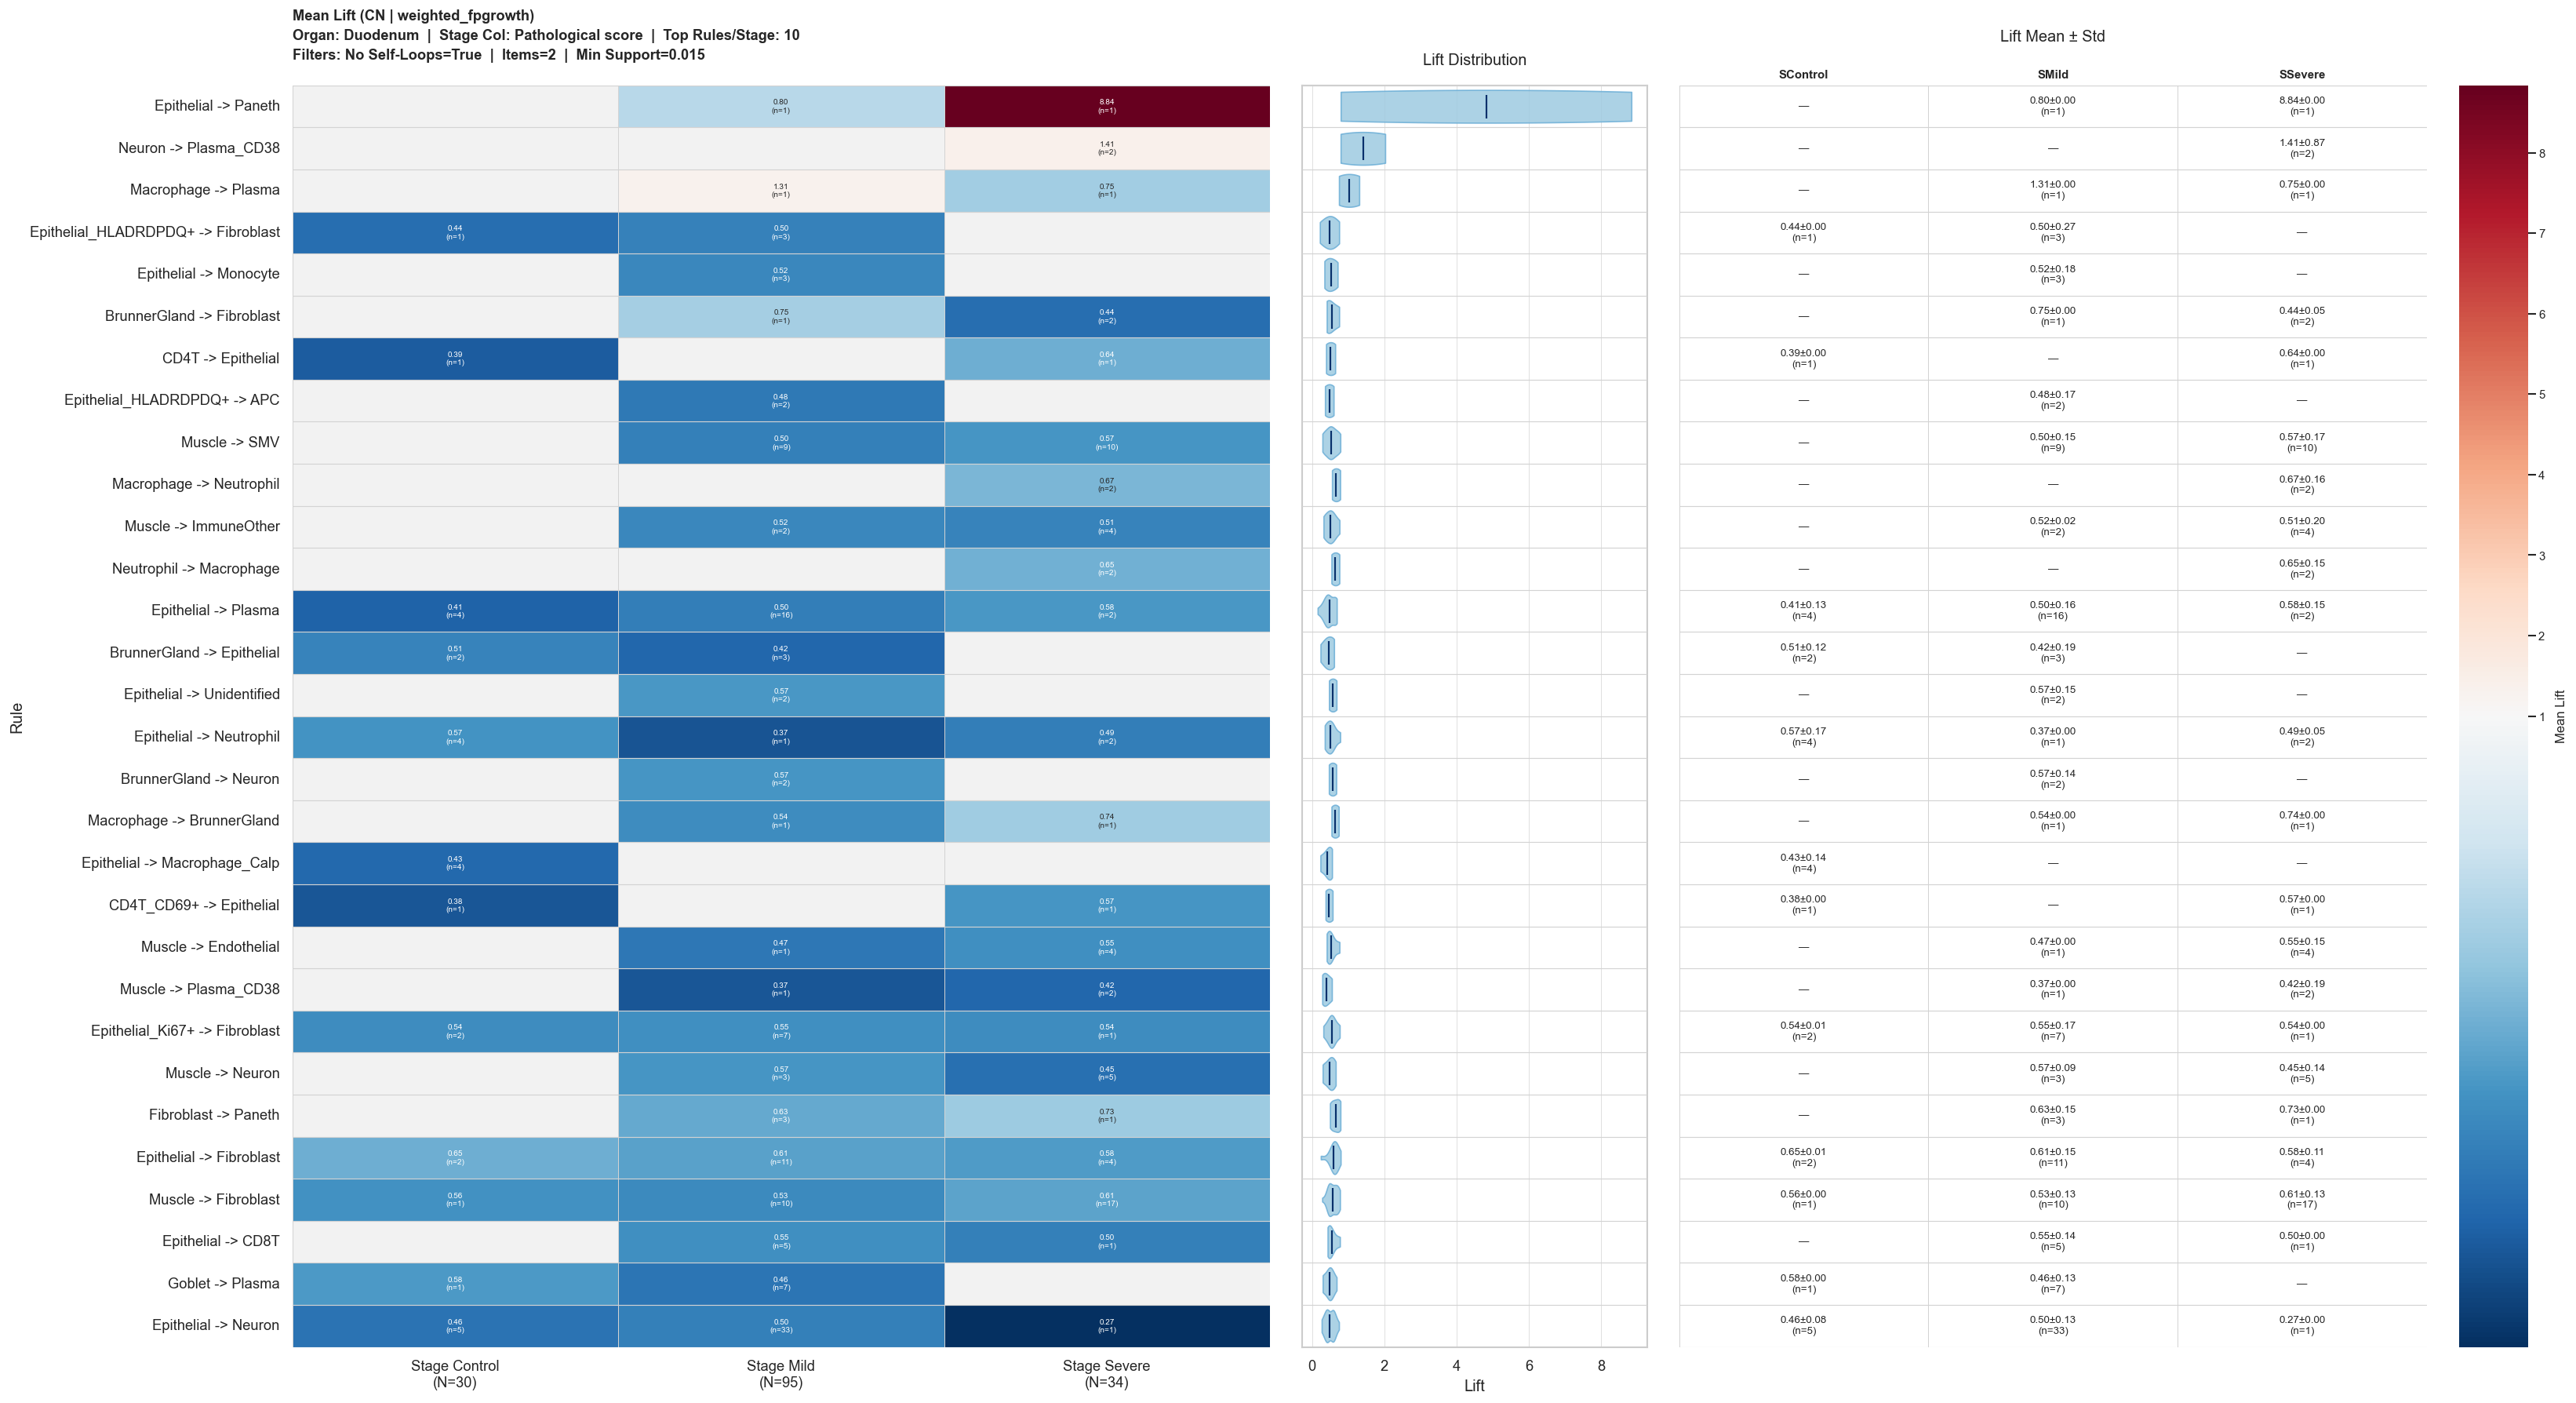

In [93]:
NO_SELF = True
confidence_heatmap_matrix, stage_consensus_df, metadata_df = _select_rules_by_global_lift_std()
heatmap_cmap = show_zero_values_as_gray()
plot_figure = plot_rule_stage_panels(
    score_matrix=confidence_heatmap_matrix,
    metadata_df=metadata_df,
    stage_count_rows=stage_consensus_df,
    heatmap_cmap=heatmap_cmap,
    colorbar_label="Mean Lift",
    heatmap_center=1.0,
)
plt.show()

### Confidence's Std Heatmap

In [94]:
def _select_rules_by_global_confidence_std():
    work_df = _create_basic_dataset()
    stage_consensus_df = build_stage_consensus(work_df)

    # Select rules by global Lift std (missing rule-FOV values are 0)
    std_view = work_df.copy()
    std_view["Rule"] = std_view.apply(
        lambda row: (
            f"{', '.join([str(x).replace('_CENTER', '').replace('_NEIGHBOR', '') for x in ast.literal_eval(row['Antecedents'])])}"
            f" -> "
        f"{', '.join([str(x).replace('_CENTER', '').replace('_NEIGHBOR', '') for x in ast.literal_eval(row['Consequents'])])}"
    ),
    axis=1,
    )

    rule_stage_fov_confidence = std_view.groupby(["Rule", STAGE_COLUMN, "FOV"], as_index=False)["Confidence"].mean()
    rule_stage_fov_confidence["Stage_FOV"] = (
        rule_stage_fov_confidence[STAGE_COLUMN].astype(str) + " | " + rule_stage_fov_confidence["FOV"].astype(str)
    )

    # Calculate global Confidence std for each rule across all stage-FOV combinations (missing values treated as 0)
    # rule_fov_confidence_matrix = rule_stage_fov_confidence.pivot(index="Rule", columns="Stage_FOV", values="Confidence").fillna(0)

    # Alternative: Calculate std only on observed values (missing values not counted as 0)""
    rule_fov_confidence_matrix = rule_stage_fov_confidence.pivot(index="Rule", columns="Stage_FOV", values="Confidence")

    rule_global_confidence_std = rule_fov_confidence_matrix.std(axis=1)

    # Keep only rules with std > 0
    rule_global_confidence_std = rule_global_confidence_std[rule_global_confidence_std > 0]

    # Pick top rules by global Confidence std
    top_rule_count = TOP_RULES_PER_STAGE * std_view[STAGE_COLUMN].nunique()
    std_selected_rules = rule_global_confidence_std.nlargest(top_rule_count).index.tolist()

    # Build stage Confidence matrix with 0 for non-existing rule-FOV values

    # stage_total_fovs = std_view.groupby(STAGE_COLUMN)["FOV"].nunique()
    # rule_stage_confidence_sum = rule_stage_fov_confidence.groupby(["Rule", STAGE_COLUMN], as_index=False)["Confidence"].sum()
    # rule_stage_confidence_sum["Stage_Total_FOVs"] = rule_stage_confidence_sum[STAGE_COLUMN].map(stage_total_fovs)
    # rule_stage_confidence_sum["Confidence_With_Missing_Zero"] = (
    #     rule_stage_confidence_sum["Confidence"] / rule_stage_confidence_sum["Stage_Total_FOVs"]
    # )
    # confidence_matrix = (
    #     rule_stage_confidence_sum.pivot(index="Rule", columns=STAGE_COLUMN, values="Confidence_With_Missing_Zero").fillna(0)
    # )

    # Without counting zero-lift rule-Fovs:

    rule_stage_confidence_observed = rule_stage_fov_confidence.groupby(["Rule", STAGE_COLUMN], as_index=False)["Confidence"].mean()
    confidence_matrix = (
        rule_stage_confidence_observed.pivot(index="Rule", columns=STAGE_COLUMN, values="Confidence")
    )

    std_selected_confidence_matrix = confidence_matrix.loc[std_selected_rules].copy()
    std_selected_confidence_matrix.columns = [str(x) for x in std_selected_confidence_matrix.columns]
    confidence_heatmap_matrix = std_selected_confidence_matrix.replace(0, np.nan)

    # Use signed confidence for heatmap colors
    signed_confidence_heatmap_matrix = np.log2(confidence_heatmap_matrix).replace([np.inf, -np.inf], np.nan)

    print("rule x stage-fov matrix shape:", rule_fov_confidence_matrix.shape)
    print("selected rules:", len(std_selected_rules))
    print("stage confidence matrix shape:", confidence_matrix.shape)
    print("selected confidence matrix shape:", std_selected_confidence_matrix.shape)
    std_selected_confidence_matrix.head(5)

    return signed_confidence_heatmap_matrix, stage_consensus_df, work_df


Filtering by organ: Duodenum
Unique stages in data for Pathological score: <StringArray>
['Control', 'Severe', 'Mild']
Length: 3, dtype: str
work_df columns: ['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction', 'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort', 'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD', 'liver stage', 'skin stage', 'Pathological stage', 'Clinical score', 'Pathological score', 'Group', 'Organ', 'ant_items', 'con_items', 'ant_clean', 'con_clean', 'ant_lineage', 'con_lineage', 'Rule']
stage_rule_counts columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
stage_consensus_df columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
rule x stage-fov matrix shape: (232, 160)
selected rules: 30
stage confidence matrix shape: (232, 3)
selected confidence matrix shape: (30

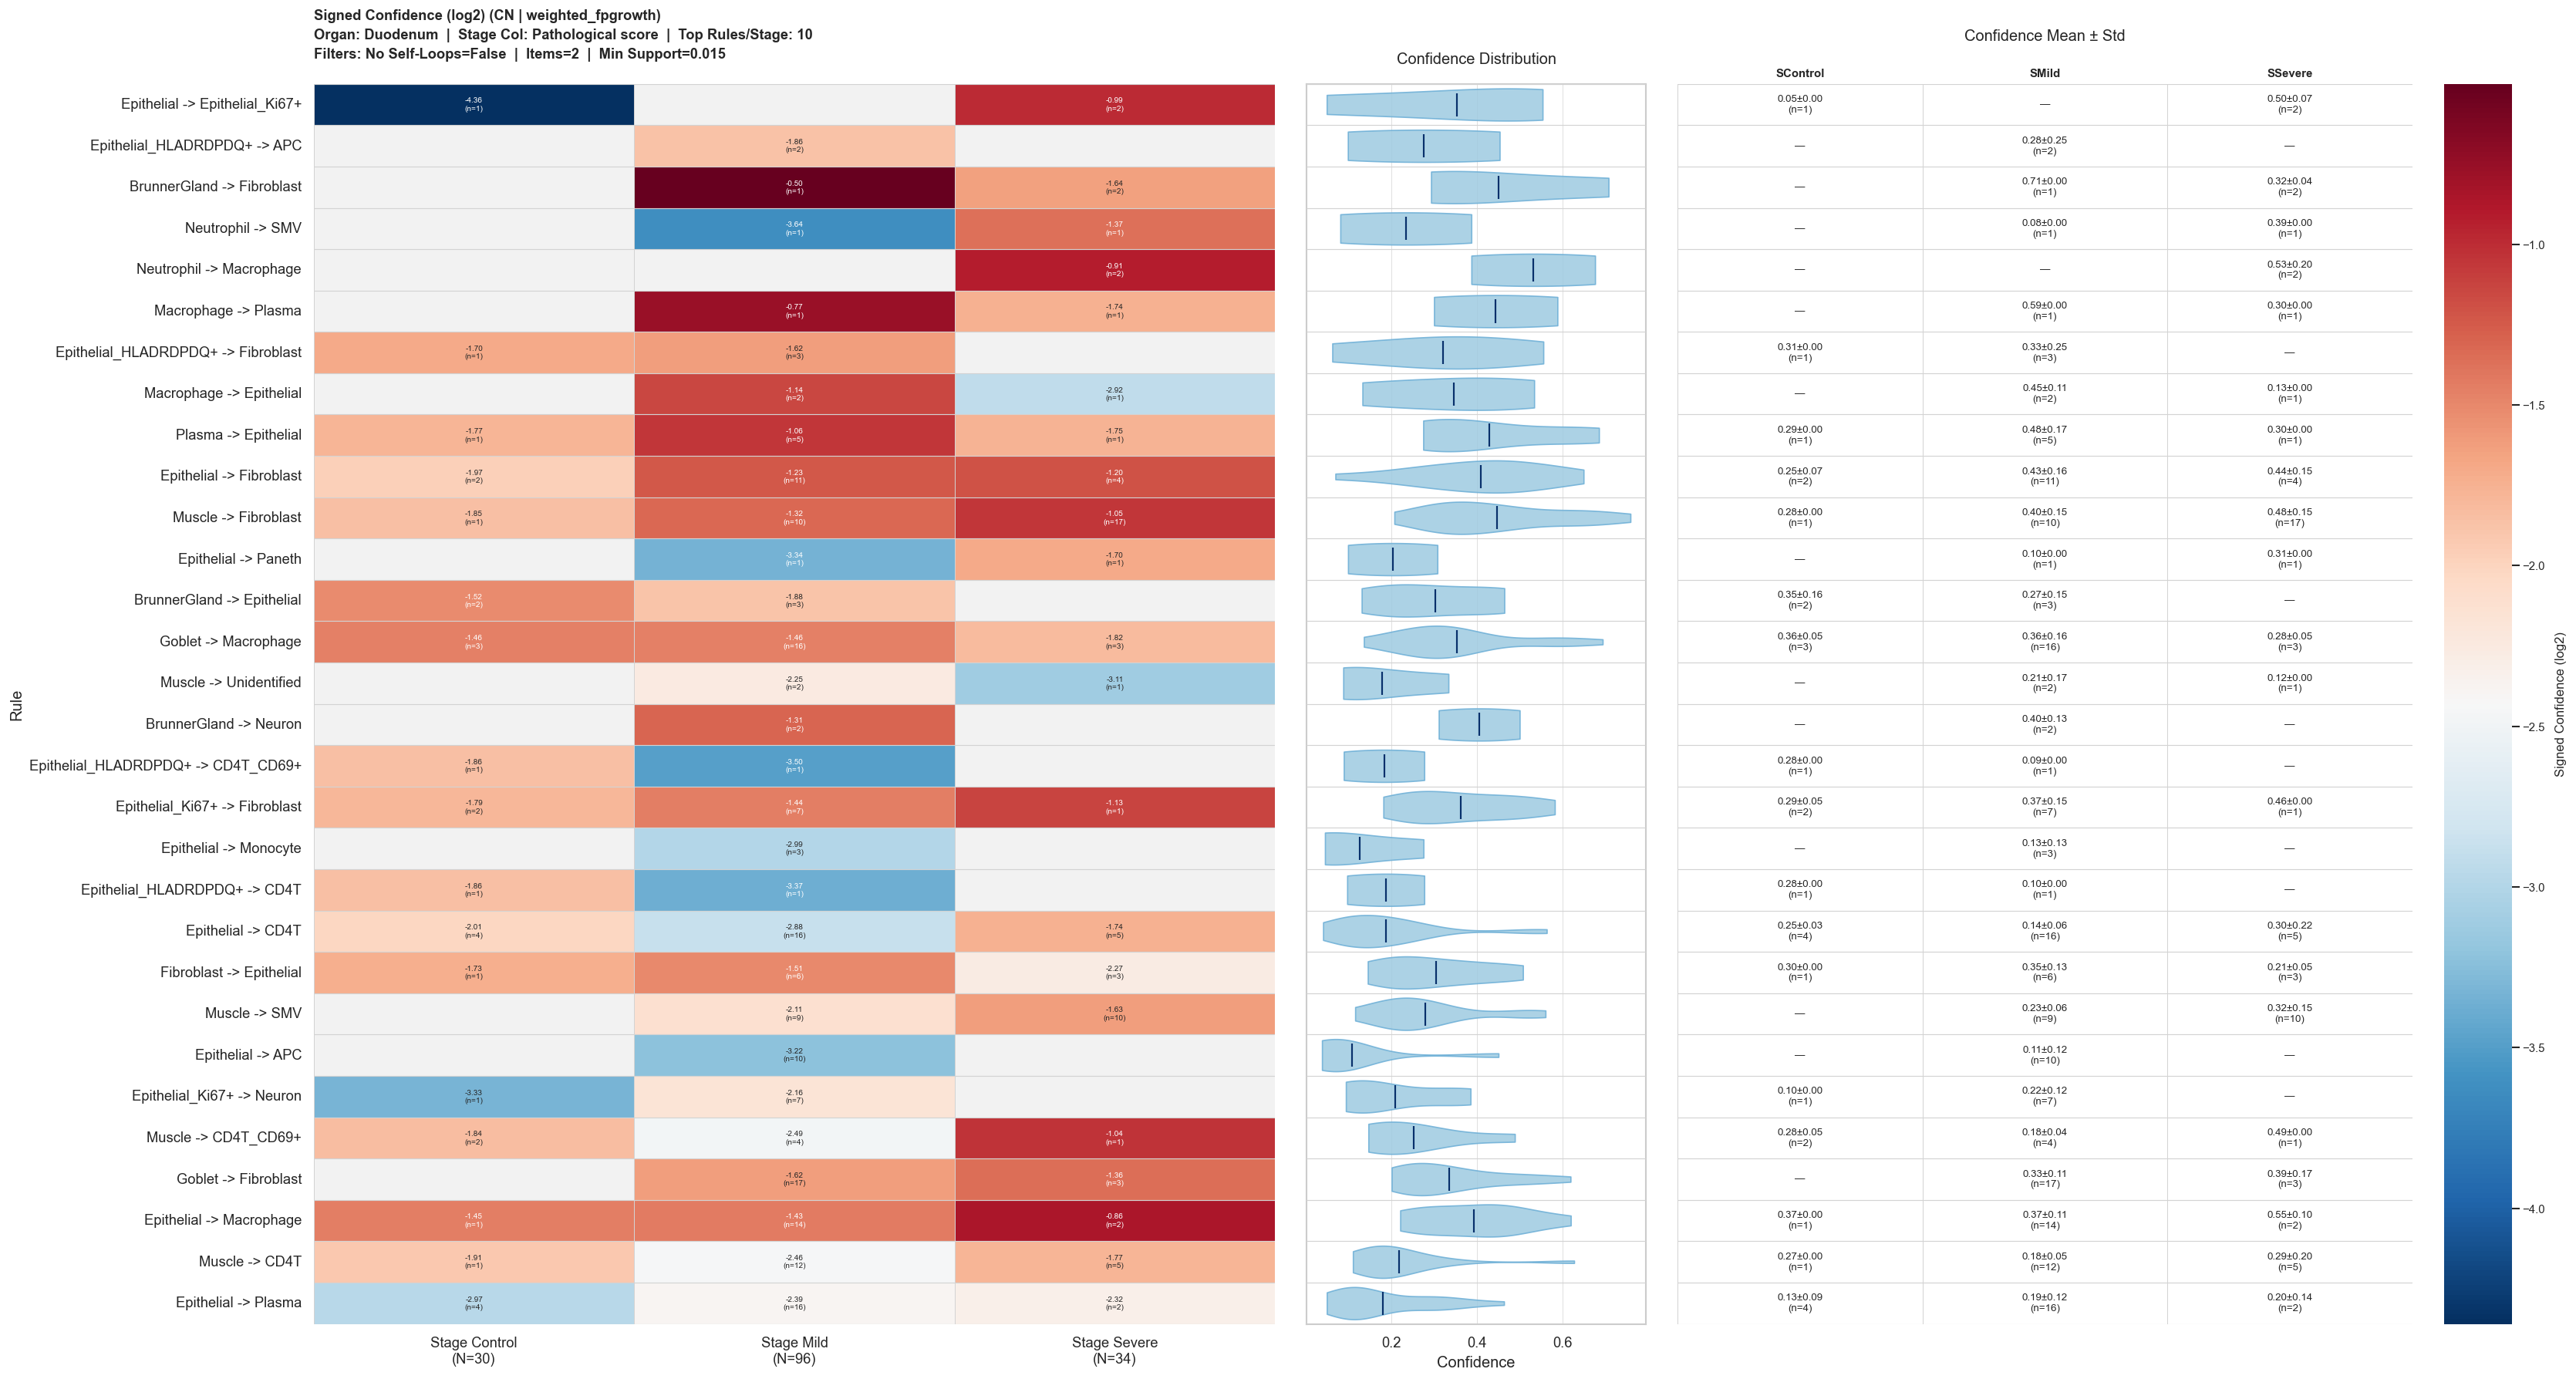

In [95]:
NO_SELF = False
signed_confidence_heatmap_matrix, stage_consensus_df, metadata_df = _select_rules_by_global_confidence_std()
heatmap_cmap = show_zero_values_as_gray("RdBu_r")
plot_figure = plot_rule_stage_panels(
    score_matrix=signed_confidence_heatmap_matrix,
    metadata_df=metadata_df,
    stage_count_rows=stage_consensus_df,
    heatmap_cmap=heatmap_cmap,
    colorbar_label="Signed Confidence (log2)",
    heatmap_center=0.0,
    metadata_value_col = "Confidence"
)
plt.show()

## Automated Manager Report Generation
Run this cell to automatically generate a multi-page PDF containing all parameter combinations.

In [96]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# 1. Define the combinations we want in the report
organs_to_run = ["Colon", "Duodenum"]
no_self_options = [False, True]

import os
import glob

# Find next running ID
existing_reports = glob.glob("reports/manager_summary_report_*.pdf")
ids = []
for f in existing_reports:
    try:
        # Extract number before .pdf (e.g., manager_summary_report_001.pdf -> 1)
        num_str = f.split("_")[-1].replace(".pdf", "")
        ids.append(int(num_str))
    except ValueError:
        pass
next_id = max(ids) + 1 if ids else 1

report_filename = f"reports/manager_summary_report_{next_id:03d}.pdf"
print(f"Generating PDF Report: {report_filename}...")

# 2. Open the PDF file for writing
with PdfPages(report_filename) as pdf:
    
    # 3. Loop through every combination
    for organ in organs_to_run:
        for no_self in no_self_options:
            
            print(f"-> Processing Organ: {organ} | No_Self: {no_self}")
            
            # OVERWRITE GLOBALS so the existing functions use these settings
            ORGAN = organ
            NO_SELF = no_self
            
            # --- PLOT 1: Consensus ---
            heatmap_df, stage_consensus_df, metadata_df = _select_rules_for_stage_consensus_view()
            if not heatmap_df.empty:
                fig1 = plot_rule_stage_panels(
                    score_matrix=heatmap_df,
                    metadata_df=metadata_df,
                    stage_count_rows=stage_consensus_df,
                )
                pdf.savefig(fig1, bbox_inches='tight')  # Save to PDF
                plt.close(fig1)                         # Close to save memory
            
            # --- PLOT 2: Mean Lift ---
            confidence_heatmap_matrix, stage_consensus_df, metadata_df = _select_rules_by_global_lift_std()
            if not confidence_heatmap_matrix.empty:
                lift_heatmap_cmap = show_zero_values_as_gray()
                fig2 = plot_rule_stage_panels(
                    score_matrix=confidence_heatmap_matrix,
                    metadata_df=metadata_df,
                    stage_count_rows=stage_consensus_df,
                    heatmap_cmap=lift_heatmap_cmap,
                    colorbar_label="Mean Lift",
                    heatmap_center=1.0,
                )
                pdf.savefig(fig2, bbox_inches='tight')
                plt.close(fig2)

            # --- PLOT 3: Signed Confidence ---
            signed_confidence_heatmap_matrix, stage_consensus_df, metadata_df = _select_rules_by_global_confidence_std()
            if not signed_confidence_heatmap_matrix.empty:
                conf_heatmap_cmap = show_zero_values_as_gray("RdBu_r")
                fig3 = plot_rule_stage_panels(
                    score_matrix=signed_confidence_heatmap_matrix,
                    metadata_df=metadata_df,
                    stage_count_rows=stage_consensus_df,
                    heatmap_cmap=conf_heatmap_cmap,
                    colorbar_label="Signed Confidence (log2)",
                    heatmap_center=0.0,
                    metadata_value_col="Confidence"
                )
                pdf.savefig(fig3, bbox_inches='tight')
                plt.close(fig3)

print("✅ PDF Report Generation Complete!")

Generating PDF Report: reports/manager_summary_report_002.pdf...
-> Processing Organ: Colon | No_Self: False
Filtering by organ: Colon
Unique stages in data for Pathological score: <StringArray>
['Severe', 'Mild', 'Control']
Length: 3, dtype: str
work_df columns: ['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction', 'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort', 'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD', 'liver stage', 'skin stage', 'Pathological stage', 'Clinical score', 'Pathological score', 'Group', 'Organ', 'ant_items', 'con_items', 'ant_clean', 'con_clean', 'ant_lineage', 'con_lineage', 'Rule']
stage_rule_counts columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
stage_consensus_df columns: ['Pathological score', 'Antecedents', 'Consequents', 'Rule', 'FOV_Count', 'Total_FOVs_In_Stage', 'Consensus_Score']
Filtering by organ: Colon
Unique